In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "examples" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import polymer_sim.recording.plot_single_run as psr

print(psr.__file__)
print([name for name in dir(psr) if "plot" in name])

import numpy as np
import matplotlib.pyplot as plt

from polymer_sim.recording.plot_single_run import plot_time_series
from polymer_sim.recording.trajectory import load_trajectory_record
from polymer_sim.recording.plot_single_run import (
    plot_reaction_interval_bar,
    plot_reaction_interval_wave,
    plot_reaction_network_state_tree,
    plot_reaction_trigger_frequency,
    plot_species_with_outflow,
)
EXAMPLES_DIR = PROJECT_ROOT / "examples"
TRAJECTORY_PATH = EXAMPLES_DIR / "compare\\outputs\\20260809_194740\\experiment_matrix\\trajectories\\beta_hybrid_local_beta_local_propensity__polymer_len10_two_stage_1_catalysis__gillespie_cle_hybrid.npz"
PROJECT_ROOT, TRAJECTORY_PATH

# "cross_catalysis_trajectory.npz"  
# "catalyst_run_trajectory.npz"
# "blended_hybrid_minimal_trajectory.npz"
# "hs2014_formal_example_trajectory.npz" 
# "oscillator_trajectory.npz"
# "cross_catalysis_SSA_trajectory.npz"
record = load_trajectory_record(TRAJECTORY_PATH)
# print("times shape:", record.times.shape)
# print("states shape:", record.states.shape)
# print("species count:", len(record.species_names))
# print("species names:", record.species_names)
# print("run metadata:", record.run_metadata)
# fast_dimerization_strict_2018_pdmp_trajectory.npz
final_state = record.states[-1]

fig, ax = plot_time_series(
    record,
    # species_indices=[6,13],
    # species_indices=["A","AA","AAAAAAAA"],
    # threshold=90,
    # time_range = (0.04903,None),
    time_lookback=10.0,
    title="Random-Catalyst Trajectory: All Species",
    log_scale= True,
    # x_log_scle= True
)
fig.set_size_inches(12, 6)
fig.tight_layout()
plt.show()
# ["1","11","111","1111","11111","00000"]

fig, ax = plot_reaction_trigger_frequency(record,species_names=["11111","1111","111","11"],legand="species_names",) # 注意其逻辑可能与你想的不同哦
plt.show()

fig, ax = plot_reaction_interval_bar(
    record,
    title="Reaction Interval Time Bar Plot",
    log=True,
)
plt.show()


C:\Users\33973\Documents\New project\polymer_sim\recording\plot_single_run.py
['_plot_reaction_interval_wave_fallback', '_resolve_time_series_plot_data', 'plot_channel_propensity_time_series', 'plot_event_time_distribution', 'plot_final_state_distribution', 'plot_mean_std_over_runs', 'plot_reaction_frequency_over_time', 'plot_reaction_interval_bar', 'plot_reaction_interval_wave', 'plot_reaction_network_state_tree', 'plot_reaction_trigger_frequency', 'plot_species_with_outflow', 'plot_time_series']


C:\Users\33973\Documents\New project\polymer_sim\recording\plot_single_run.py:190: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


KeyboardInterrupt: 

windows:
(0.0, 0.3, '0-0.3')
(0.3, 0.4, '0.3-0.4')
(0.4, None, '0.4-None')
event_times range: 5.969724951226519e-06 0.40306337458285346
n_event_times: 43814
n_intervals: 43814
0-0.3: window=(0.0, 0.3) n_times=30632 n_intervals=30632 n_values=30632
0.3-0.4: window=(0.3, 0.4) n_times=12636 n_intervals=12636 n_values=12636
0.4-None: window=(0.4, None) n_times=546 n_intervals=546 n_values=546
time_window
0-0.3       30632
0.3-0.4     12636
0.4-None      546
Name: count, dtype: int64


d:\Users\33973\miniconda3\envs\warm_pool\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
d:\Users\33973\miniconda3\envs\warm_pool\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
d:\Users\33973\miniconda3\envs\warm_pool\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
d:\Users\33973\miniconda3\envs\warm_pool\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layo

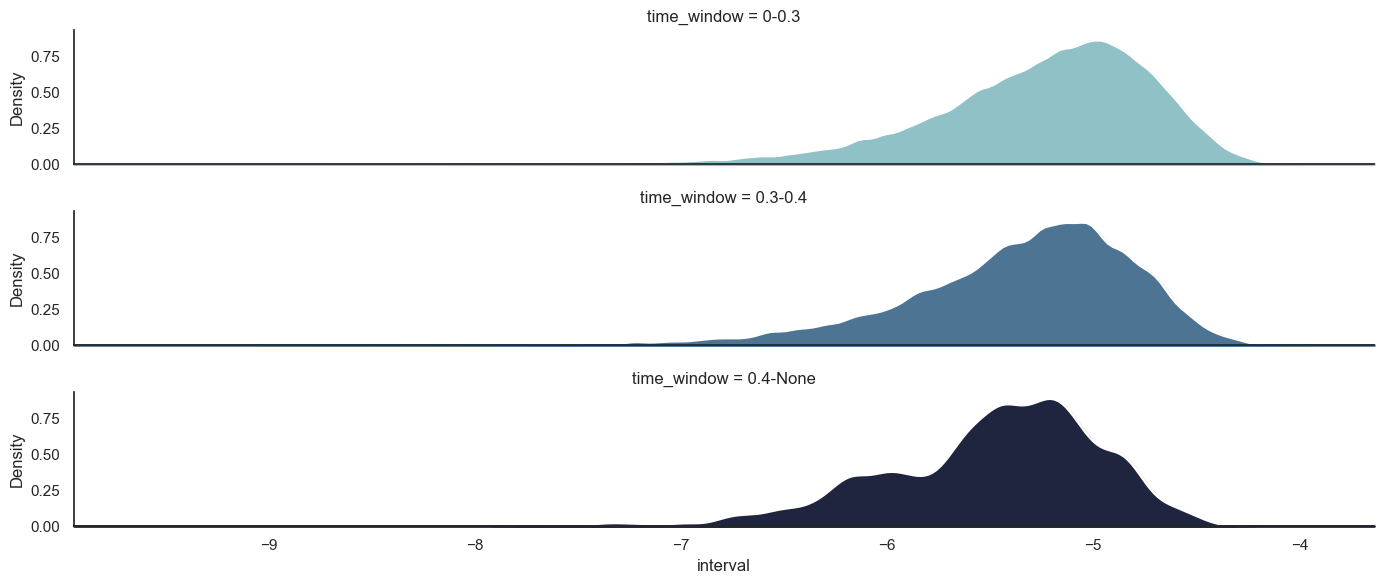

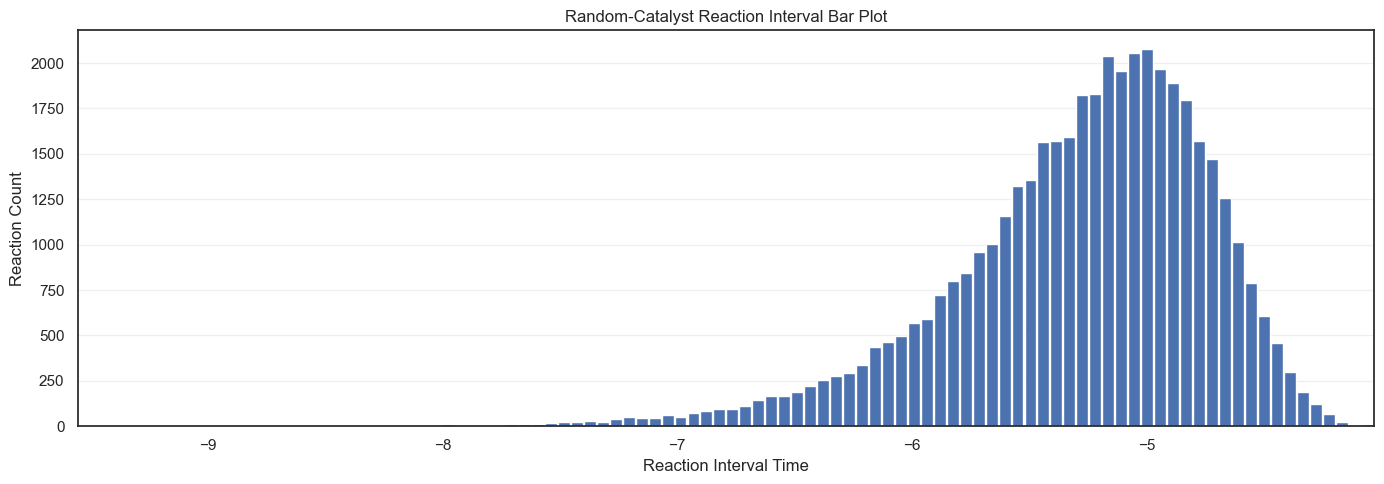

In [3]:
# Time window segments: each row is one editable segment.
# start is included, end is excluded; end=None means through the trajectory end.
REACTION_INTERVAL_TIME_WINDOWS = [
    {"label": "0-0.3", "start": 0.0, "end": 0.3},
    {"label": "0.3-0.4", "start": 0.3, "end": 0.4},
    {"label": "0.4-None", "start": 0.4, "end": None},
]

REACTION_INTERVAL_BAR_TIME_RANGE = (0.0, None)

REACTION_INTERVAL_WAVE_LOG_SCALE = True

fig, grid = plot_reaction_interval_wave(
    record,
    time_windows=REACTION_INTERVAL_TIME_WINDOWS,
    title="Random-Catalyst Reaction Interval Wave Plot by Time Window",
    n_bins=100,
    log=REACTION_INTERVAL_WAVE_LOG_SCALE,
)
fig.set_size_inches(14, 6)
fig.tight_layout()
plt.show()

fig, ax = plot_reaction_interval_bar(
    record,
    title="Random-Catalyst Reaction Interval Bar Plot",
    n_bars=100,
    log=REACTION_INTERVAL_WAVE_LOG_SCALE,
    time_range=REACTION_INTERVAL_BAR_TIME_RANGE,
)
fig.set_size_inches(14, 5)
fig.tight_layout()
plt.show()
